# BÀI TẬP VỀ NHÀ: PyTorch Basics
**Sinh viên:** Đoàn Tấn Minh Tân

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cpu


---
## Bài 1: Đạo hàm và Gradient Descent
Hàm: $y = x^3 + 2x^2 + 5x + 1$

In [2]:
# 1.1: Tính dy/dx tại x = 2
x = torch.tensor(2.0, requires_grad=True)
y = x**3 + 2*x**2 + 5*x + 1
y.backward()

print(f'y tại x=2       : {y.item():.4f}')
print(f'dy/dx (PyTorch) : {x.grad.item():.4f}')
print(f'dy/dx (tay)     : {3*4 + 4*2 + 5}  (3x²+4x+5 tại x=2 = 12+8+5 = 25)')
print(f'Khớp nhau       : {abs(x.grad.item() - 25) < 1e-4}')

y tại x=2       : 27.0000
dy/dx (PyTorch) : 25.0000
dy/dx (tay)     : 25  (3x²+4x+5 tại x=2 = 12+8+5 = 25)
Khớp nhau       : True


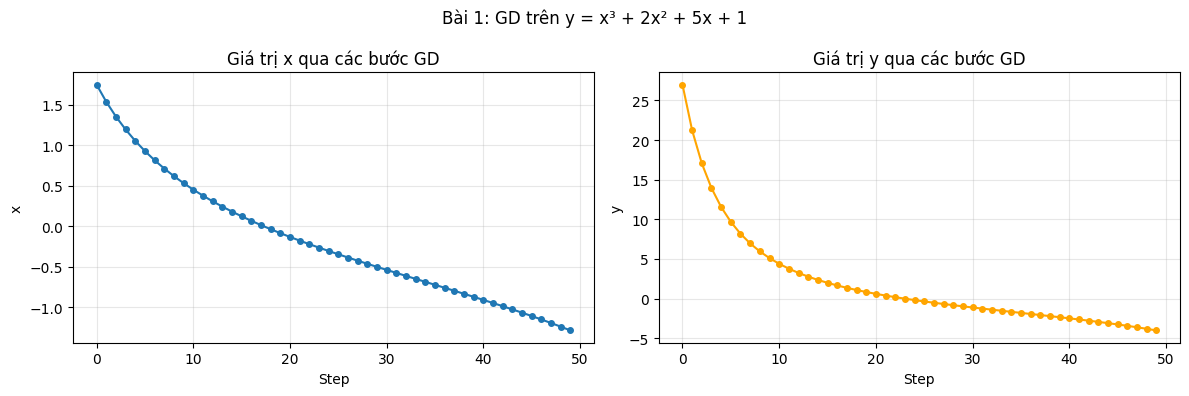

x sau 50 bước: -1.2835
y sau 50 bước: -4.0179


In [3]:
# 1.2: Gradient Descent 50 vòng, lr=0.01
x = torch.tensor(2.0, requires_grad=True)
lr = 0.01
history_x, history_y = [], []

for step in range(50):
    y = x**3 + 2*x**2 + 5*x + 1
    y.backward()

    with torch.no_grad():
        x -= lr * x.grad
        x.grad.zero_()

    history_x.append(x.item())
    history_y.append(y.item())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_x, 'o-', markersize=4)
axes[0].set_xlabel('Step'); axes[0].set_ylabel('x')
axes[0].set_title('Giá trị x qua các bước GD')
axes[0].grid(alpha=0.3)

axes[1].plot(history_y, 'o-', color='orange', markersize=4)
axes[1].set_xlabel('Step'); axes[1].set_ylabel('y')
axes[1].set_title('Giá trị y qua các bước GD')
axes[1].grid(alpha=0.3)

plt.suptitle('Bài 1: GD trên y = x³ + 2x² + 5x + 1')
plt.tight_layout()
plt.show()

print(f'x sau 50 bước: {history_x[-1]:.4f}')
print(f'y sau 50 bước: {history_y[-1]:.4f}')

### Nhận xét Bài 1

**x hội tụ về đâu?**  
Với `lr=0.01` xuất phát từ $x=2$, x liên tục giảm về phía âm và không dừng lại — y cũng giảm theo không có điểm dừng.

**Có phải cực tiểu thật không?**  
Không. Phương trình đạo hàm $y' = 3x^2 + 4x + 5 = 0$ có biệt số $\Delta = 16 - 60 = -44 < 0$ → vô nghiệm thực → hàm **đơn điệu tăng** trên $\mathbb{R}$, không có cực tiểu. Gradient descent sẽ chạy mãi về $-\infty$. Đây là bài học quan trọng: GD chỉ tìm được nghiệm nếu hàm thực sự có cực tiểu.

---
## Bài 2: Hồi quy tuyến tính bằng GD thủ công

In [4]:
# Tạo dữ liệu giả lập
torch.manual_seed(42)
N = 50
x_data = torch.rand(N) * 9 + 1          # [1, 10]
eps    = torch.randn(N) * 0.5
y_data = 3 * x_data + 5 + eps           # y = 3x + 5 + noise

# Khởi tạo tham số
w = torch.tensor(0.0, requires_grad=True)
b = torch.tensor(0.0, requires_grad=True)

lr = 0.01
n_epochs = 200
loss_history = []

for epoch in range(n_epochs):
    # Forward: dự đoán và tính loss MSE
    y_pred = w * x_data + b
    loss   = ((y_data - y_pred) ** 2).mean()

    # Backward
    loss.backward()

    # Update tham số
    with torch.no_grad():
        w -= lr * w.grad
        b -= lr * b.grad
        w.grad.zero_()
        b.grad.zero_()

    loss_history.append(loss.item())

    if (epoch + 1) % 20 == 0:
        print(f'Epoch {epoch+1:3d}/200 | w={w.item():.4f}  b={b.item():.4f}  loss={loss.item():.4f}')

Epoch  20/200 | w=3.6131  b=0.7552  loss=2.6711
Epoch  40/200 | w=3.5812  b=0.9800  loss=2.4122
Epoch  60/200 | w=3.5511  b=1.1926  loss=2.1805
Epoch  80/200 | w=3.5225  b=1.3937  loss=1.9734
Epoch 100/200 | w=3.4956  b=1.5839  loss=1.7881
Epoch 120/200 | w=3.4700  b=1.7638  loss=1.6223
Epoch 140/200 | w=3.4459  b=1.9339  loss=1.4741
Epoch 160/200 | w=3.4231  b=2.0947  loss=1.3415
Epoch 180/200 | w=3.4015  b=2.2469  loss=1.2229
Epoch 200/200 | w=3.3811  b=2.3908  loss=1.1168


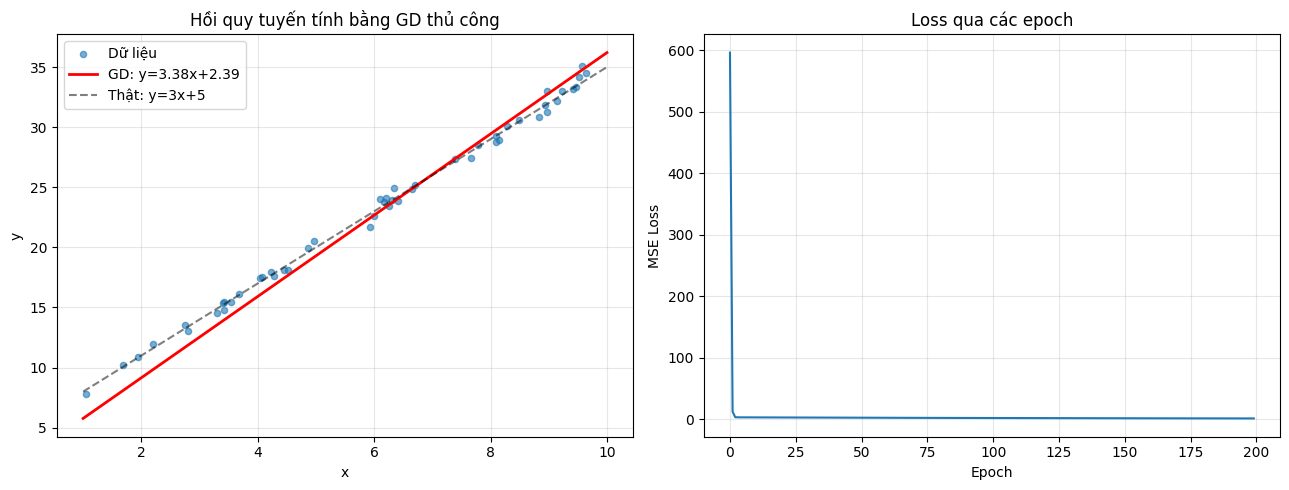


Kết quả cuối cùng : w=3.3811, b=2.3908
Giá trị thật      : w=3.0000, b=5.0000
Sai số w          : 0.3811
Sai số b          : 2.6092


In [5]:
# Vẽ kết quả
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Đường thẳng học được vs dữ liệu
x_line = torch.linspace(1, 10, 100)
y_line = w.detach() * x_line + b.detach()

axes[0].scatter(x_data.numpy(), y_data.numpy(), s=20, alpha=0.6, label='Dữ liệu')
axes[0].plot(x_line.numpy(), y_line.numpy(), color='red', linewidth=2,
             label=f'GD: y={w.item():.2f}x+{b.item():.2f}')
axes[0].plot(x_line.numpy(), (3*x_line+5).numpy(), 'k--', alpha=0.5, label='Thật: y=3x+5')
axes[0].set_xlabel('x'); axes[0].set_ylabel('y')
axes[0].set_title('Hồi quy tuyến tính bằng GD thủ công')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Loss curve
axes[1].plot(loss_history)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MSE Loss')
axes[1].set_title('Loss qua các epoch')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\nKết quả cuối cùng : w={w.item():.4f}, b={b.item():.4f}')
print(f'Giá trị thật      : w=3.0000, b=5.0000')
print(f'Sai số w          : {abs(w.item()-3):.4f}')
print(f'Sai số b          : {abs(b.item()-5):.4f}')

---
## Bài 3: Tạo tensor với các phương thức khác nhau

In [6]:
print('=== torch.empty(3, 4) ===')
print(torch.empty(3, 4))

print('\n=== torch.zeros(2, 3) ===')
print(torch.zeros(2, 3))

print('\n=== torch.ones(4) ===')
print(torch.ones(4))

print('\n=== torch.rand(3, 3) — phân phối đều [0,1] ===')
print(torch.rand(3, 3))

print('\n=== torch.randn(3, 3) — phân phối chuẩn N(0,1) ===')
print(torch.randn(3, 3))

print('\n=== view và view_as ===')
t = torch.arange(12).reshape(2, 6)
print(f'Tensor t ban đầu, shape {t.shape}:')
print(t)

t_view = t.view(3, 4)
print(f'\nt.view(3, 4), shape {t_view.shape}:')
print(t_view)

template = torch.zeros(3, 4)    # tensor mẫu có shape (3,4)
t_view_as = t.view_as(template)
print(f'\nt.view_as(template shape={template.shape}), shape {t_view_as.shape}:')
print(t_view_as)

=== torch.empty(3, 4) ===
tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])

=== torch.zeros(2, 3) ===
tensor([[0., 0., 0.],
        [0., 0., 0.]])

=== torch.ones(4) ===
tensor([1., 1., 1., 1.])

=== torch.rand(3, 3) — phân phối đều [0,1] ===
tensor([[0.5782, 0.0600, 0.2846],
        [0.2007, 0.5014, 0.3139],
        [0.4654, 0.1612, 0.1568]])

=== torch.randn(3, 3) — phân phối chuẩn N(0,1) ===
tensor([[-0.9648, -1.6645,  0.2046],
        [ 0.7237,  0.1275, -1.1140],
        [ 0.5139,  0.0760, -0.0740]])

=== view và view_as ===
Tensor t ban đầu, shape torch.Size([2, 6]):
tensor([[ 0,  1,  2,  3,  4,  5],
        [ 6,  7,  8,  9, 10, 11]])

t.view(3, 4), shape torch.Size([3, 4]):
tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])

t.view_as(template shape=torch.Size([3, 4])), shape torch.Size([3, 4]):
tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])


---
## Bài 4: Hàm hai biến
$f(x, y) = x^2 + 2y^2 + 3xy + x + y$

In [7]:
# 4.1: Tính đạo hàm riêng tại (x,y) = (1,2)
x = torch.tensor(1.0, requires_grad=True)
y = torch.tensor(2.0, requires_grad=True)
f = x**2 + 2*y**2 + 3*x*y + x + y
f.backward()

print(f'f(1,2)        = {f.item():.4f}')
print(f'∂f/∂x PyTorch = {x.grad.item():.4f}  |  tay: 2(1)+3(2)+1 = 9')
print(f'∂f/∂y PyTorch = {y.grad.item():.4f}  |  tay: 4(2)+3(1)+1 = 12')
print(f'Khớp ∂f/∂x   : {abs(x.grad.item()-9)  < 1e-4}')
print(f'Khớp ∂f/∂y   : {abs(y.grad.item()-12) < 1e-4}')

f(1,2)        = 18.0000
∂f/∂x PyTorch = 9.0000  |  tay: 2(1)+3(2)+1 = 9
∂f/∂y PyTorch = 12.0000  |  tay: 4(2)+3(1)+1 = 12
Khớp ∂f/∂x   : True
Khớp ∂f/∂y   : True


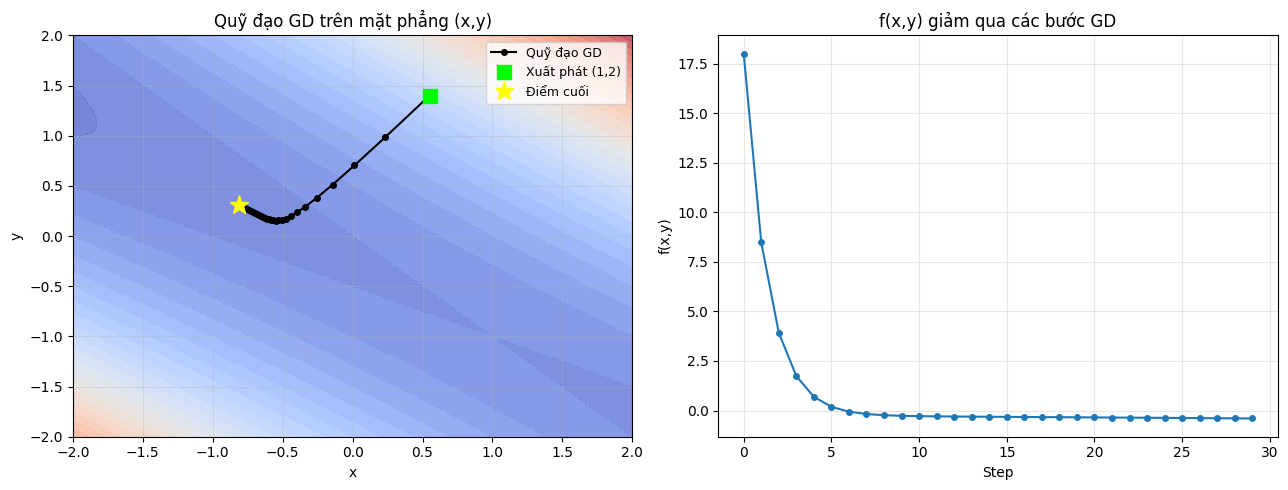

Điểm cuối: x=-0.8134, y=0.3071, f=-0.3989


In [8]:
# 4.3: Gradient Descent đồng thời x và y
x = torch.tensor(1.0, requires_grad=True)
y = torch.tensor(2.0, requires_grad=True)
lr = 0.05

traj_x, traj_y, traj_f = [], [], []

for step in range(30):
    f = x**2 + 2*y**2 + 3*x*y + x + y
    f.backward()

    with torch.no_grad():
        x -= lr * x.grad
        y -= lr * y.grad
        x.grad.zero_()
        y.grad.zero_()

    traj_x.append(x.item())
    traj_y.append(y.item())
    traj_f.append(f.item())

# Vẽ quỹ đạo trên mặt phẳng (x,y)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Contour map của f
xg = np.linspace(-2, 2, 200)
yg = np.linspace(-2, 2, 200)
Xg, Yg = np.meshgrid(xg, yg)
Fg = Xg**2 + 2*Yg**2 + 3*Xg*Yg + Xg + Yg

axes[0].contourf(Xg, Yg, Fg, levels=30, cmap='coolwarm', alpha=0.7)
axes[0].contour(Xg, Yg, Fg, levels=30, colors='white', linewidths=0.4, alpha=0.4)
axes[0].plot(traj_x, traj_y, 'o-', color='black', markersize=4, label='Quỹ đạo GD')
axes[0].plot(traj_x[0], traj_y[0], 's', color='lime', markersize=10, label='Xuất phát (1,2)')
axes[0].plot(traj_x[-1], traj_y[-1], '*', color='yellow', markersize=14, label='Điểm cuối')
axes[0].set_xlabel('x'); axes[0].set_ylabel('y')
axes[0].set_title('Quỹ đạo GD trên mặt phẳng (x,y)')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

# f qua các bước
axes[1].plot(traj_f, 'o-', markersize=4)
axes[1].set_xlabel('Step'); axes[1].set_ylabel('f(x,y)')
axes[1].set_title('f(x,y) giảm qua các bước GD')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Điểm cuối: x={traj_x[-1]:.4f}, y={traj_y[-1]:.4f}, f={traj_f[-1]:.4f}')